In [1]:
# ============================================================
# NOTEBOOK 4: STATISTICAL TESTING
# ============================================================

import sys
sys.path.append('src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load graph features
graph_features = pd.read_csv('data/processed/graph_features_final.csv')

# Load labels
from load_data import load_elliptic_data, clean_and_merge, split_labeled_unlabeled
features, classes, edges = load_elliptic_data('data')
df = clean_and_merge(features, classes)
df_all, df_labeled = split_labeled_unlabeled(df)

# Merge graph features with labels
df_analysis = df_labeled[['txId', 'label']].merge(graph_features, on='txId')

print("=" * 60)
print("STATISTICAL TESTING SETUP")
print("=" * 60)
print(f"\n✅ Analysis dataset: {df_analysis.shape}")
print(f"   Illicit: {(df_analysis['label'] == 1).sum():,}")
print(f"   Licit:   {(df_analysis['label'] == 0).sum():,}")
print(f"\n📊 Features to test: {len(graph_features.columns) - 1}")  # minus txId

STATISTICAL TESTING SETUP

✅ Analysis dataset: (46564, 9)
   Illicit: 4,545
   Licit:   42,019

📊 Features to test: 7


In [2]:
# ============================================================
# CELL 2: MANN-WHITNEY U TESTS + EFFECT SIZES
# ============================================================

print("=" * 70)
print("MANN-WHITNEY U TESTS: ILLICIT vs. LICIT")
print("=" * 70)

# Separate illicit and licit
illicit = df_analysis[df_analysis['label'] == 1]
licit = df_analysis[df_analysis['label'] == 0]

# Features to test (exclude txId and label)
feature_cols = [c for c in df_analysis.columns if c not in ['txId', 'label']]

# Store results
results = []

print("\n📊 Running Mann-Whitney U tests for each feature...")
print("   H0: Illicit and licit distributions are identical")
print("   H1: Distributions differ (two-sided test)")
print("\n" + "-" * 70)

for feature in feature_cols:
    # Get values
    illicit_vals = illicit[feature].values
    licit_vals = licit[feature].values
    
    # Mann-Whitney U test
    statistic, p_value = stats.mannwhitneyu(illicit_vals, licit_vals, alternative='two-sided')
    
    # Effect size: rank-biserial correlation (r = Z / sqrt(N))
    # Approximate Z from U statistic
    n1, n2 = len(illicit_vals), len(licit_vals)
    mean_u = n1 * n2 / 2
    std_u = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z_score = (statistic - mean_u) / std_u
    effect_size = abs(z_score) / np.sqrt(n1 + n2)
    
    # Interpret effect size
    if effect_size < 0.1:
        effect_interpretation = "Negligible"
    elif effect_size < 0.3:
        effect_interpretation = "Small"
    elif effect_size < 0.5:
        effect_interpretation = "Medium"
    else:
        effect_interpretation = "Large"
    
    # Medians
    illicit_median = np.median(illicit_vals)
    licit_median = np.median(licit_vals)
    
    results.append({
        'feature': feature,
        'illicit_median': illicit_median,
        'licit_median': licit_median,
        'difference': illicit_median - licit_median,
        'u_statistic': statistic,
        'p_value': p_value,
        'effect_size': effect_size,
        'effect_interpretation': effect_interpretation,
        'significant': p_value < 0.05
    })
    
    # Print result
    sig_marker = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    direction = "higher" if illicit_median > licit_median else "lower"
    
    print(f"\n📈 {feature}")
    print(f"   Illicit median: {illicit_median:.6f}")
    print(f"   Licit median:   {licit_median:.6f}")
    print(f"   Difference:     {illicit_median - licit_median:.6f} (illicit {direction})")
    print(f"   p-value:        {p_value:.2e} {sig_marker}")
    print(f"   Effect size:    {effect_size:.3f} ({effect_interpretation})")

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('effect_size', ascending=False)

print("\n" + "=" * 70)
print("SUMMARY TABLE (sorted by effect size)")
print("=" * 70)
print(results_df[['feature', 'illicit_median', 'licit_median', 'p_value', 'effect_size', 'effect_interpretation']].to_string(index=False))

# Count significant results
sig_count = results_df['significant'].sum()
print(f"\n✅ Significant results: {sig_count}/{len(results_df)} features (p < 0.05)")

# Save results
results_df.to_csv('results/mann_whitney_results.csv', index=False)
print(f"\n💾 Saved: results/mann_whitney_results.csv")

MANN-WHITNEY U TESTS: ILLICIT vs. LICIT

📊 Running Mann-Whitney U tests for each feature...
   H0: Illicit and licit distributions are identical
   H1: Distributions differ (two-sided test)

----------------------------------------------------------------------

📈 in_degree
   Illicit median: 1.000000
   Licit median:   1.000000
   Difference:     0.000000 (illicit lower)
   p-value:        5.55e-11 ***
   Effect size:    0.028 (Negligible)

📈 out_degree
   Illicit median: 1.000000
   Licit median:   1.000000
   Difference:     0.000000 (illicit lower)
   p-value:        1.44e-118 ***
   Effect size:    0.098 (Negligible)

📈 total_degree
   Illicit median: 1.000000
   Licit median:   2.000000
   Difference:     -1.000000 (illicit lower)
   p-value:        6.84e-188 ***
   Effect size:    0.128 (Small)

📈 pagerank
   Illicit median: 0.000003
   Licit median:   0.000003
   Difference:     0.000000 (illicit higher)
   p-value:        3.55e-01 ns
   Effect size:    0.004 (Negligible)

📈 cl

FEATURE DISTRIBUTION COMPARISON: ILLICIT vs. LICIT


TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

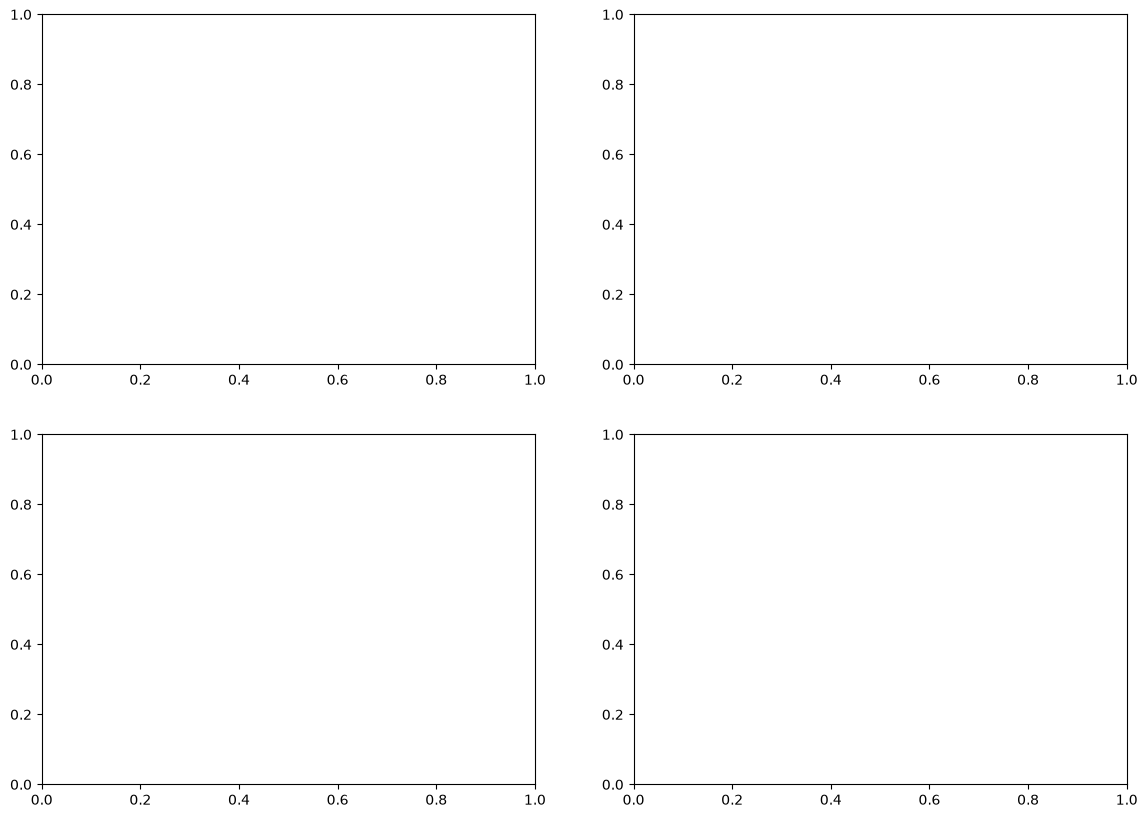

In [3]:
# ============================================================
# CELL 3: VISUALIZATION — BOX PLOTS
# ============================================================

print("=" * 60)
print("FEATURE DISTRIBUTION COMPARISON: ILLICIT vs. LICIT")
print("=" * 60)

# Features to plot (top 4 by effect size)
plot_features = ['total_degree', 'weak_component_size', 'out_degree', 'k_core']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(plot_features):
    ax = axes[idx]
    
    # Get data
    illicit_vals = df_analysis[df_analysis['label'] == 1][feature]
    licit_vals = df_analysis[df_analysis['label'] == 0][feature]
    
    # Box plot
    bp = ax.boxplot([licit_vals, illicit_vals], 
                    labels=['Licit', 'Illicit'],
                    patch_artist=True,
                    widths=0.6)
    
    # Color boxes
    bp['boxes'][0].set_facecolor('#3498db')  # Blue for licit
    bp['boxes'][1].set_facecolor('#e74c3c')  # Red for illicit
    
    # Add median values as text
    licit_median = licit_vals.median()
    illicit_median = illicit_vals.median()
    
    ax.text(1, licit_median, f'Median: {licit_median:.1f}', 
            ha='center', va='bottom', fontsize=10, color='#3498db', fontweight='bold')
    ax.text(2, illicit_median, f'Median: {illicit_median:.1f}', 
            ha='center', va='bottom', fontsize=10, color='#e74c3c', fontweight='bold')
    
    ax.set_title(f'{feature.upper()}\n(p < 0.001, effect size: Small)', 
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Value', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Graph Features: Illicit vs. Licit Transactions\n(Elliptic Bitcoin Dataset)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/statistical_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ Saved: figures/statistical_boxplots.png")

FEATURE DISTRIBUTION COMPARISON: ILLICIT vs. LICIT


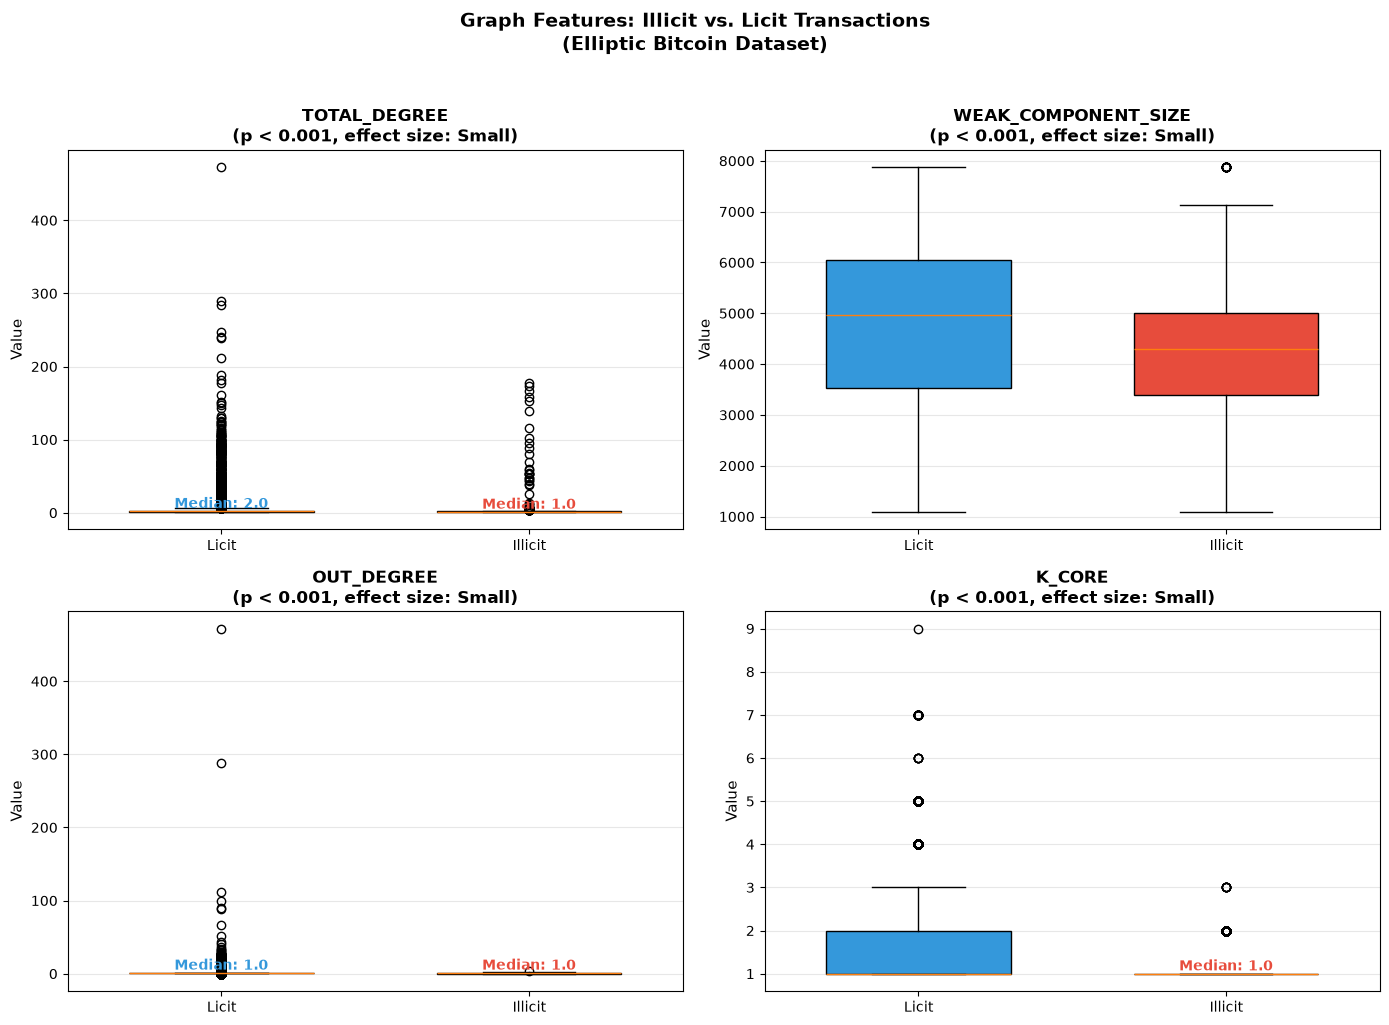


✅ Saved: figures/statistical_boxplots.png


In [4]:
# ============================================================
# CELL 3: VISUALIZATION — BOX PLOTS (FIXED)
# ============================================================

print("=" * 60)
print("FEATURE DISTRIBUTION COMPARISON: ILLICIT vs. LICIT")
print("=" * 60)

# Features to plot (top 4 by effect size)
plot_features = ['total_degree', 'weak_component_size', 'out_degree', 'k_core']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(plot_features):
    ax = axes[idx]
    
    # Get data
    illicit_vals = df_analysis[df_analysis['label'] == 1][feature]
    licit_vals = df_analysis[df_analysis['label'] == 0][feature]
    
    # Box plot - use tick_labels instead of labels
    bp = ax.boxplot([licit_vals, illicit_vals], 
                    tick_labels=['Licit', 'Illicit'],  # ✅ FIXED: tick_labels
                    patch_artist=True,
                    widths=0.6)
    
    # Color boxes
    bp['boxes'][0].set_facecolor('#3498db')  # Blue for licit
    bp['boxes'][1].set_facecolor('#e74c3c')  # Red for illicit
    
    # Add median values as text
    licit_median = licit_vals.median()
    illicit_median = illicit_vals.median()
    
    ax.text(1, licit_median, f'Median: {licit_median:.1f}', 
            ha='center', va='bottom', fontsize=10, color='#3498db', fontweight='bold')
    ax.text(2, illicit_median, f'Median: {illicit_median:.1f}', 
            ha='center', va='bottom', fontsize=10, color='#e74c3c', fontweight='bold')
    
    ax.set_title(f'{feature.upper()}\n(p < 0.001, effect size: Small)', 
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Value', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Graph Features: Illicit vs. Licit Transactions\n(Elliptic Bitcoin Dataset)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/statistical_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ Saved: figures/statistical_boxplots.png")

In [5]:
# ============================================================
# CELL 4: EFFECT SIZE SUMMARY TABLE (For Paper)
# ============================================================

print("=" * 70)
print("EFFECT SIZE SUMMARY TABLE")
print("=" * 70)

# Create publication-ready summary
summary = results_df[['feature', 'illicit_median', 'licit_median', 'p_value', 'effect_size', 'effect_interpretation']].copy()

# Format for readability
summary['illicit_median'] = summary['illicit_median'].round(4)
summary['licit_median'] = summary['licit_median'].round(4)
summary['p_value'] = summary['p_value'].apply(lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.3f}")
summary['effect_size'] = summary['effect_size'].round(3)

# Rename columns for paper
summary.columns = ['Feature', 'Illicit Median', 'Licit Median', 'p-value', 'Effect Size (r)', 'Interpretation']

print("\n📊 Table 1: Mann-Whitney U Test Results (Illicit vs. Licit)")
print("-" * 70)
print(summary.to_string(index=False))

print("\n" + "=" * 70)
print("NOTEBOOK 4 COMPLETE")
print("=" * 70)
print("\n📁 Files created:")
print("   • results/mann_whitney_results.csv")
print("   • figures/statistical_boxplots.png")
print("\n✅ Ready for Notebook 5: Modeling")

EFFECT SIZE SUMMARY TABLE

📊 Table 1: Mann-Whitney U Test Results (Illicit vs. Licit)
----------------------------------------------------------------------
            Feature  Illicit Median  Licit Median   p-value  Effect Size (r) Interpretation
       total_degree             1.0           2.0 6.84e-188            0.128          Small
weak_component_size          4296.0        4975.0 6.43e-166            0.127          Small
         out_degree             1.0           1.0 1.44e-118            0.098     Negligible
             k_core             1.0           1.0 1.34e-119            0.089     Negligible
          in_degree             1.0           1.0  5.55e-11            0.028     Negligible
         clustering             0.0           0.0  1.10e-31            0.018     Negligible
           pagerank             0.0           0.0     0.355            0.004     Negligible

NOTEBOOK 4 COMPLETE

📁 Files created:
   • results/mann_whitney_results.csv
   • figures/statistical_boxpl